0it [00:00, ?it/s]

15it [05:47, 23.15s/it]


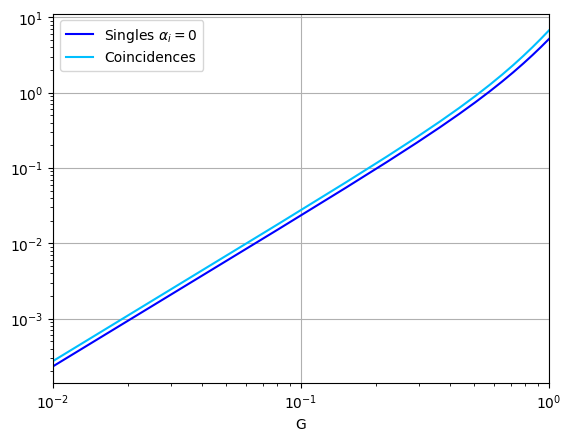

In [ ]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
# Use __file__ if running as a script, or fallback to the current working directory if in Jupyter
current_dir = Path(__file__).resolve() if '__file__' in locals() else Path.cwd()
# Go up two levels to get the root directory
root_dir = current_dir.parents[1] if '__file__' in locals() else current_dir.parent
# Safely inject the directory to Python's search path
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))
from singles import OptimalPhase, OptFisherInfo
from coincidences import FisherInfo
from tqdm import tqdm

G=np.linspace(1e-2,1,15)                                 #? Gain
T=0.9                               #? T
t_s1=np.sqrt(T)                     #? τ_s1
t_i1=np.sqrt(T)                     #? τ_i1
t_s2=np.sqrt(T)                     #? τ_s2
t_i2=t_s2                           #? τ_i2  
a_i=1

F_noseed = OptFisherInfo(a_i=0,G=G,t_s1=t_s1,t_i1=t_i1,t_s2=t_s2)
F_seed = OptFisherInfo(a_i=a_i,G=G,t_s1=t_s1,t_i1=t_i1,t_s2=t_s2)

G_coin = np.linspace(G.min(),G.max(),15)
F_coin = np.zeros_like(G_coin)
phi_approx = OptimalPhase(a_i=0,G=G_coin,t_s1=t_s1,t_i1=t_i1,t_s2=t_s2)
nmax = np.array([5,5,5,5,5,10,10,10,10,15,30,30,30,40,50])

for i,g in tqdm(np.ndenumerate(G_coin)):
    phi_probe = np.linspace(phi_approx[i],np.pi,10)
    F_probe = np.zeros(3)
    for j in range(3):
        F_probe[j]=FisherInfo(nmax[i],phi=phi_probe[j], G=g, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2, t_i2=t_i2)
    F_coin[i] = F_probe.max()

fig,ax = plt.subplots()
G_ticks=np.hstack((10**np.arange(np.log10(G.min()),0),np.arange(1,G.max()+1,1)))
ax.plot(G,F_noseed, color="blue", label=r"Singles $\alpha_i=0$")
ax.plot(G_coin,F_coin, color="deepskyblue", label="Coincidences")
ax.set_xlabel('G')
ax.set_xlim([G.min(),G.max()])
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True)
ax.set_xticks(G_ticks)
ax.legend()


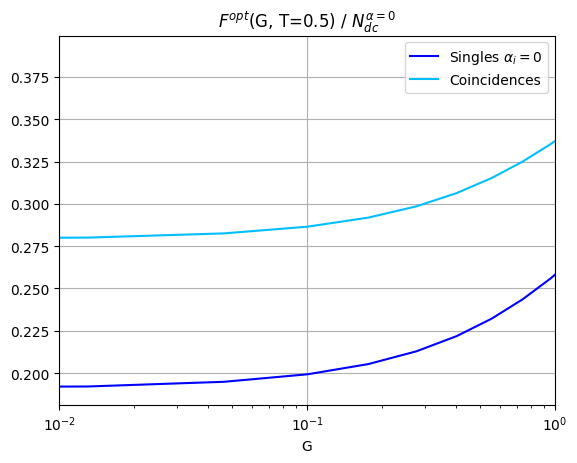

In [3]:
NT=2*abs(np.sinh(G))**2
NT_coin=2*abs(np.sinh(G_coin))**2

fig,ax = plt.subplots()
G_ticks=np.hstack((10**np.arange(np.log10(G.min()),0),np.arange(1,G.max()+1,1)))
ax.plot(NT,F_noseed/NT, color="blue", label=r"Singles $\alpha_i=0$")
ax.plot(NT_coin,F_coin/NT, color="deepskyblue", label="Coincidences")
ax.set_title(rf"$F^{{opt}}$(G, T={T:.1f}) / $N_{{dc}}^{{\alpha=0}}$")
ax.set_xlabel('G')
ax.set_xlim([G.min(),G.max()])
ax.set_xscale("log")
ax.grid(True)
ax.set_xticks(G_ticks)
ax.legend()

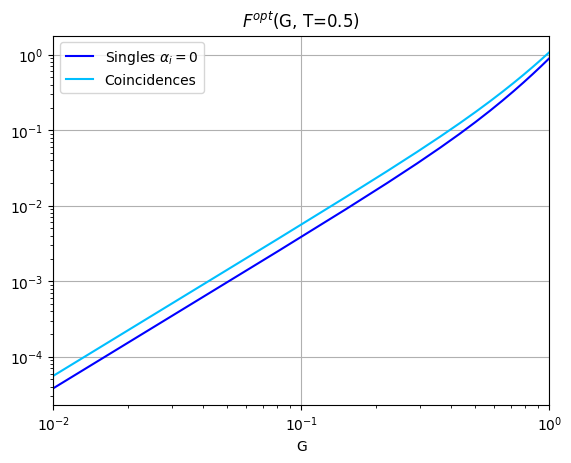

In [4]:
fig,ax = plt.subplots()
G_ticks=np.hstack((10**np.arange(np.log10(G.min()),0),np.arange(1,G.max()+1,1)))
ax.plot(G,F_noseed, color="blue", label=r"Singles $\alpha_i=0$")
ax.plot(G_coin,F_coin, color="deepskyblue", label="Coincidences")
ax.set_title(rf"$F^{{opt}}$(G, T={T:.1f})")
ax.set_xlabel('G')
ax.set_xlim([G.min(),G.max()])
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True)
ax.set_xticks(G_ticks)
ax.legend()
